# 원룸 사진 기반 3D 공간 복원 및 거리 측정  (v3.0 - 거리측정)

평면도 자동 생성 대신, 복원된 3D 공간에서 **두 점을 직접 클릭해 실측 거리를 재는 방식**으로 전환한 버전이다.
YOLO11 / SAM2 객체 검출·분할은 거리 측정에 불필요하므로 제거했다. 필요해지면 v2.0에서 복사해 오면 된다.

스케일 기준은 **천장고**다 (한국 주거 표준 2.3~2.4m).

구성: 0 환경설정 / 1 데이터 / 2 DUSt3R 복원 / 2-1 입력 진단 / 3 좌표 정렬(핵심) / 4 GLB 저장 / 5 천장고 기반 스케일 계산 / 6 두 점 클릭 거리 측정


## 0. 환경 설정

In [1]:
import os
import sys
import glob
import shutil
import numpy as np
from PIL import Image

# DUSt3R 저장소 클론 (이미 존재하면 건너뜀)
if not os.path.exists("/content/dust3r"):
    !git clone --recursive https://github.com/naver/dust3r.git /content/dust3r

%cd /content/dust3r
!pip install -q -r requirements.txt
!pip install -q open3d shapely trimesh scipy roma plotly
%cd /content

# DUSt3R 모듈 경로 등록 (중복 방지)
if "/content/dust3r" not in sys.path:
    sys.path.insert(0, "/content/dust3r")


Cloning into '/content/dust3r'...
remote: Enumerating objects: 611, done.
remote: Total 611 (delta 0), reused 0 (delta 0), pack-reused 611 (from 1)
Receiving objects: 100% (611/611), 756.60 KiB | 30.26 MiB/s, done.
Resolving deltas: 100% (355/355), done.
Submodule 'croco' (https://github.com/naver/croco) registered for path 'croco'
Cloning into '/content/dust3r/croco'...
remote: Enumerating objects: 198, done.        
remote: Counting objects: 100% (87/87), done.        
remote: Compressing objects: 100% (54/54), done.        
remote: Total 198 (delta 54), reused 33 (delta 33), pack-reused 111 (from 1)        
Receiving objects: 100% (198/198), 403.93 KiB | 31.07 MiB/s, done.
Resolving deltas: 100% (94/94), done.
Submodule path 'croco': checked out 'd7de0705845239092414480bd829228723bf20de'
/content/dust3r
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [2]:
# 한글 폰트 설치 및 matplotlib 등록
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("한글 폰트 설정 완료")


한글 폰트 설정 완료


## 1. 데이터 다운로드 및 폴더 선택

In [3]:
# Google Drive 폴더 다운로드
!gdown --folder 1ivpuKwZ25BosAlM9-YnROKlNPpPk-6Op

print("\n다운로드된 파일 목록")
for root, dirs, files in os.walk("/content/02_Data"):
    for f in files:
        print(" ", os.path.join(root, f))


Retrieving folder contents
Retrieving folder 1k-GNamI93_NOriowcsIvOfSp9GSRegYZ test1
Processing file 1rmq_AYaEFBhAck5jY4b5ZjMl6BI1T_xY 6a2faabef0290_origin.jpg
Processing file 1RslFQoYRD-DifKArz3-_VqDIkbGfO7us 6a2faabf730ea_origin.jpg
Processing file 19UKbayjY5MTRgvOD560XT53nCyHFVsPT 6a2faabfd9ec4_origin.jpg
Retrieving folder 1Vc3jELHuMdiTWyAZG_C1dYF-rgEyrgEP test2
Processing file 1hTKUCsuDIVaoa5FDo7F4cR24LbA1S5OM 1.jpg
Processing file 1U-aDSyb8yVBewj04ZJGDD-en27ZYa8ku 2.jpg
Processing file 1d3hwWNyczH4NpEEUFXWOqs9B2WWVXraq 3.jpg
Processing file 1lf1OnrnRMnuVlKyAsddAv5gm729FyjqL 4.jpg
Retrieving folder 1EwQ3izk-BKU2739p5rTXmRmUM1whDQEk test3
Processing file 1_8LUa0WoOSjqNg3oOyNgBkWly_msN8tE KakaoTalk_20260623_190119914_02.jpg
Processing file 1tK5SJcqd1zAaKSBBbb4BwYxGoDqDYmjV KakaoTalk_20260623_190119914_03.jpg
Processing file 1_ifH74t4m7hSzcjC_Nj9XJXSBCBtfjZr KakaoTalk_20260623_190119914.jpg
Retrieving folder 1rrfNUL18Mfe9UYCewgvBs0IdHghSp-KT test4
Processing file 19bkajJzjn9LQQyHhdPtd

In [4]:
# 처리 대상 폴더 지정
# 선택지: test1 / test2 / test3 / test4 / 직방사진
TARGET_FOLDER = "직방사진"

# 신뢰도 임계값 (DUSt3R confidence 필터링 기준)
CONF_THR = 1.0

# 이미지 경로 수집
target_path = f"/content/02_Data/{TARGET_FOLDER}"
img_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
    img_paths.extend(glob.glob(os.path.join(target_path, ext)))
img_paths = sorted(img_paths)

print(f"[{TARGET_FOLDER}] 이미지 {len(img_paths)}장")
for p in img_paths:
    print(" ", os.path.basename(p))

# 이후 단계에서 원본 PIL 이미지가 필요하므로 미리 로드
images_pil = [Image.open(p).convert("RGB") for p in img_paths]


[직방사진] 이미지 5장
  방1.png
  방2.png
  방3.png
  방4.png
  방5.png


## 2. 3D 복원 (DUSt3R)

In [5]:
import torch
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.inference import inference
from dust3r.cloud_opt import global_aligner

# DUSt3R 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device)
model.eval()
print(f"DUSt3R 모델 로드 완료 (device: {device})")


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


/content/dust3r/dust3r/cloud_opt/base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/450 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

DUSt3R 모델 로드 완료 (device: cuda)


In [6]:
# 이미지 로드 및 쌍 구성 후 추론
images_dust3r = load_images(img_paths, size=512)
pairs = make_pairs(images_dust3r, scene_graph="complete", prefilter=None, symmetrize=True)
print(f"이미지 쌍 {len(pairs)}개 구성")

with torch.no_grad():
    output = inference(pairs, model, device, batch_size=2)

# Global alignment로 전체 좌표계 정렬
scene = global_aligner(output, device=device)
scene.compute_global_alignment(niter=300, init="mst")
print("3D 복원 및 정렬 완료")


>> Loading a list of 5 images
 - adding /content/02_Data/직방사진/방1.png with resolution 1180x884 --> 512x384
 - adding /content/02_Data/직방사진/방2.png with resolution 1188x890 --> 512x384
 - adding /content/02_Data/직방사진/방3.png with resolution 1178x884 --> 512x384
 - adding /content/02_Data/직방사진/방4.png with resolution 1182x886 --> 512x384
 - adding /content/02_Data/직방사진/방5.png with resolution 1182x890 --> 512x384
 (Found 5 images)
이미지 쌍 20개 구성
>> Inference with model on 20 image pairs


  0%|          | 0/10 [00:00<?, ?it/s]/content/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/content/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/content/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 10/10 [00:05<00:00,  1.79it/s]


 init edge (1*,3*) score=np.float64(204.28628540039062)
 init edge (3,4*) score=np.float64(198.2686309814453)
 init edge (2*,1) score=np.float64(159.57301330566406)
 init edge (0*,1) score=np.float64(129.0702362060547)
 init loss = 0.016754167154431343
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


  0%|          | 0/300 [00:00<?, ?it/s]/content/dust3r/dust3r/cloud_opt/base_opt.py:366: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(loss), lr
100%|██████████| 300/300 [00:09<00:00, 31.72it/s, lr=1.27413e-06 loss=0.00970822]

3D 복원 및 정렬 완료


## 2-1. 입력 품질 진단

In [7]:
# --- confidence 통계 ---
conf_list = [c.detach().cpu().numpy() for c in scene.get_conf()]

print("=== 뷰별 confidence ===")
for i, c in enumerate(conf_list):
    print(f"  view {i}: mean={c.mean():.2f}  median={np.median(c):.2f}  "
          f"min={c.min():.2f}  max={c.max():.2f}")

overall = np.mean([c.mean() for c in conf_list])
print(f"\n전체 평균 confidence: {overall:.2f}")
if overall < 3.0:
    print(">> 경고: confidence가 낮다. 복원이 부정확할 가능성이 높다.")
    print(">> 시점이 더 겹치는 사진을 쓰거나 장수를 늘리는 게 근본 해결책이다.")
else:
    print(">> confidence 양호.")


=== 뷰별 confidence ===
  view 0: mean=2.31  median=2.45  min=0.00  max=3.36
  view 1: mean=2.72  median=2.80  min=0.00  max=3.48
  view 2: mean=2.64  median=2.74  min=0.07  max=3.26
  view 3: mean=2.61  median=2.80  min=0.00  max=3.33
  view 4: mean=2.57  median=2.65  min=0.43  max=3.09

전체 평균 confidence: 2.57
>> 경고: confidence가 낮다. 복원이 부정확할 가능성이 높다.
>> 시점이 더 겹치는 사진을 쓰거나 장수를 늘리는 게 근본 해결책이다.


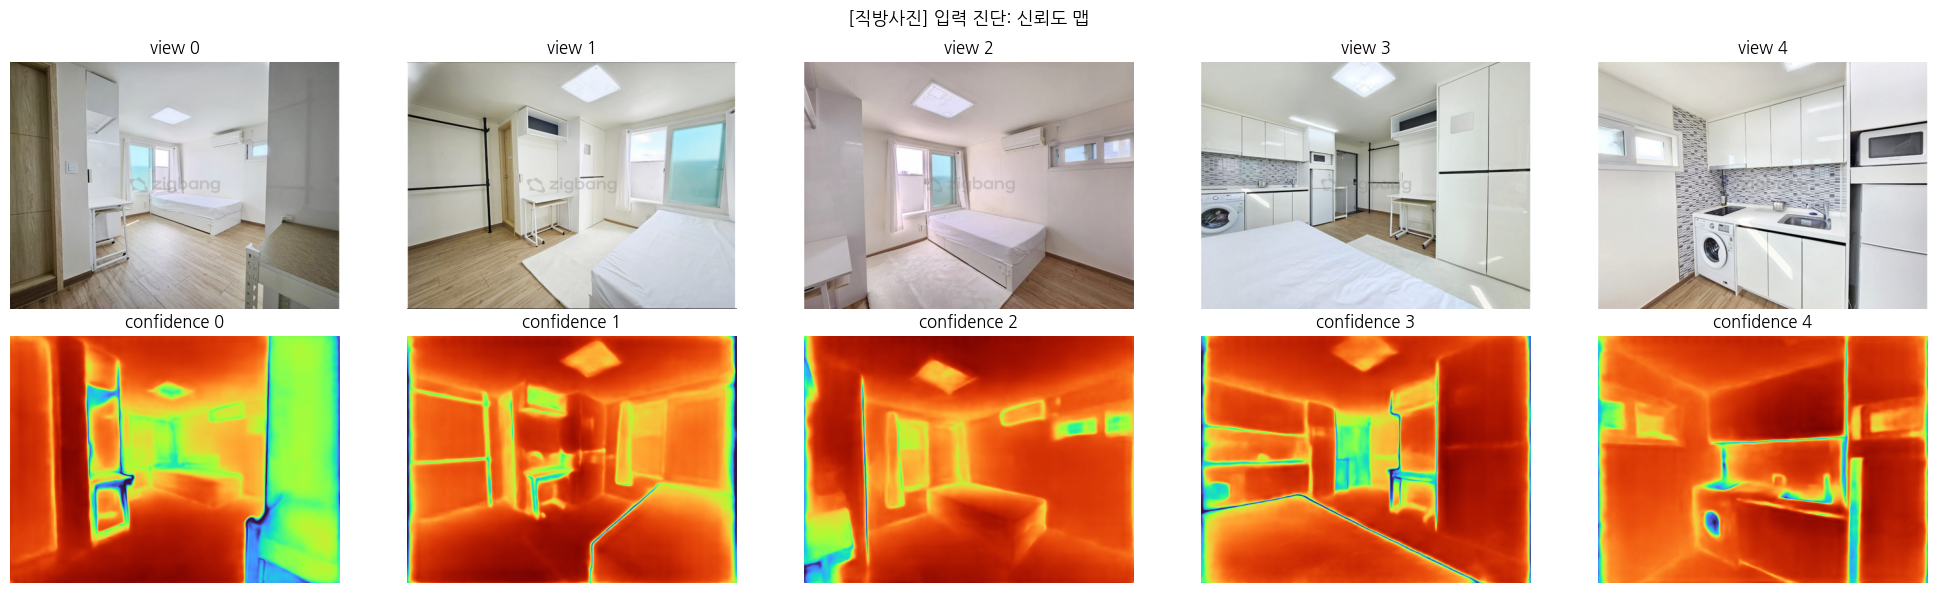

아래쪽: 파란색=신뢰낮음(창/단색벽/반사), 빨간색=신뢰높음


In [8]:
# --- confidence 맵 시각화 ---
imgs_np = scene.imgs   # 정규화된 입력 (H,W,3), 0~1
n = len(imgs_np)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 6))
if n == 1:
    axes = np.array(axes).reshape(2, 1)
for i in range(n):
    axes[0, i].imshow(imgs_np[i]); axes[0, i].set_title(f"view {i}"); axes[0, i].axis("off")
    axes[1, i].imshow(conf_list[i], cmap="turbo")
    axes[1, i].set_title(f"confidence {i}"); axes[1, i].axis("off")
plt.suptitle(f"[{TARGET_FOLDER}] 입력 진단: 신뢰도 맵", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("아래쪽: 파란색=신뢰낮음(창/단색벽/반사), 빨간색=신뢰높음")


**확인 포인트 — 입력 진단 해석**
- confidence가 전반적으로 낮으면 거리 측정값도 신뢰하기 어렵다. 시점이 겹치는 사진을 더 확보하는 게 근본 해결책이다.
- 카메라 분산이 너무 작으면(한 자리에서만 찍음) 복원이 평면적으로 무너져 거리 오차가 커진다.


## 3. 정렬 좌표 생성 (핵심)

DUSt3R raw 좌표 → GLB 변환 → 바닥 RANSAC 정렬까지 한 번에 처리한다.
이 좌표계(`all_pts`, `ALIGN_TRANSFORM`)가 이후 GLB 저장, 스케일 계산, 거리 측정에서 공통으로 쓰인다.
높이축은 Y(=1).

In [9]:
import trimesh
from scipy.spatial.transform import Rotation

try:
    from dust3r.demo import OPENGL
except ImportError:
    from dust3r.viz import OPENGL

cams2world = scene.get_im_poses().detach().cpu().numpy()
_rot = np.eye(4)
_rot[:3, :3] = Rotation.from_euler("y", np.deg2rad(180)).as_matrix()
GLB_TRANSFORM = np.linalg.inv(cams2world[0] @ OPENGL @ _rot)


def apply_transform(points, T):
    """(N,3) 점에 4x4 변환 적용"""
    pts_h = np.concatenate([points, np.ones((len(points), 1))], axis=1)
    out = (T @ pts_h.T).T
    return out[:, :3]


def find_floor_rotation(points, up_axis=1, n_iter=2000):
    """RANSAC으로 바닥 평면을 검출하고, 그 법선을 +Y축에 맞추는 4x4 회전 행렬 반환"""
    height = points[:, up_axis]
    floor_candidates = points[height <= np.percentile(height, 35)]
    if len(floor_candidates) < 3:
        return np.eye(4), np.array([0.0, 1.0, 0.0])

    diag = np.linalg.norm(points.max(0) - points.min(0))
    threshold = diag * 0.02

    best_inliers, best_normal = -1, np.array([0.0, 1.0, 0.0])
    for _ in range(n_iter):
        idx = np.random.choice(len(floor_candidates), 3, replace=False)
        p1, p2, p3 = floor_candidates[idx]
        normal = np.cross(p2 - p1, p3 - p1)
        nrm = np.linalg.norm(normal)
        if nrm < 1e-6:
            continue
        normal = normal / nrm
        d = -np.dot(normal, p1)
        dist = np.abs(floor_candidates @ normal + d)
        ninl = int((dist < threshold).sum())
        if ninl > best_inliers:
            best_inliers, best_normal = ninl, normal

    if best_normal[up_axis] < 0:
        best_normal = -best_normal

    target = np.array([0.0, 1.0, 0.0])
    v = np.cross(best_normal, target)
    s = np.linalg.norm(v)
    c = float(np.dot(best_normal, target))
    if s < 1e-8:
        R = np.eye(3)
    else:
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        R = np.eye(3) + vx + vx @ vx * ((1 - c) / (s * s))

    T = np.eye(4)
    T[:3, :3] = R
    return T, best_normal


# DUSt3R 결과에서 바로 포인트/색상 수집 (YOLO·SAM2 불필요)
pointmaps = scene.get_pts3d()
confidences = scene.get_conf()

_all_pts_raw, _all_cols = [], []
for i, pts in enumerate(pointmaps):
    pts_np = pts.detach().cpu().numpy().reshape(-1, 3)
    conf_np = confidences[i].detach().cpu().numpy().flatten()
    mask = conf_np > CONF_THR
    h, w = pts.shape[:2]
    img_resized = np.array(images_pil[i].resize((w, h))).reshape(-1, 3)
    _all_pts_raw.append(pts_np[mask])
    _all_cols.append(img_resized[mask])
_all_pts_raw = np.concatenate(_all_pts_raw, axis=0)
all_cols = np.concatenate(_all_cols, axis=0) / 255.0

_all_pts_glb = apply_transform(_all_pts_raw, GLB_TRANSFORM)
FLOOR_ROT, floor_normal = find_floor_rotation(_all_pts_glb)
print(f"검출된 바닥 법선(GLB좌표): [{floor_normal[0]:+.2f}, {floor_normal[1]:+.2f}, {floor_normal[2]:+.2f}]")

ALIGN_TRANSFORM = FLOOR_ROT @ GLB_TRANSFORM


def align_points(points_raw):
    """raw DUSt3R 좌표(N,3) -> 정렬 좌표(N,3). 바닥이 수평, +Y가 위."""
    return apply_transform(points_raw, ALIGN_TRANSFORM)


all_pts = align_points(_all_pts_raw)

print(f"\n정렬 완료. 전체 포인트 수: {len(all_pts):,}")
print("이제 all_pts 는 바닥이 수평으로 정렬된 좌표다. 높이축은 Y(=1).")


검출된 바닥 법선(GLB좌표): [+0.16, +0.95, -0.25]

정렬 완료. 전체 포인트 수: 960,596
이제 all_pts 는 바닥이 수평으로 정렬된 좌표다. 높이축은 Y(=1).


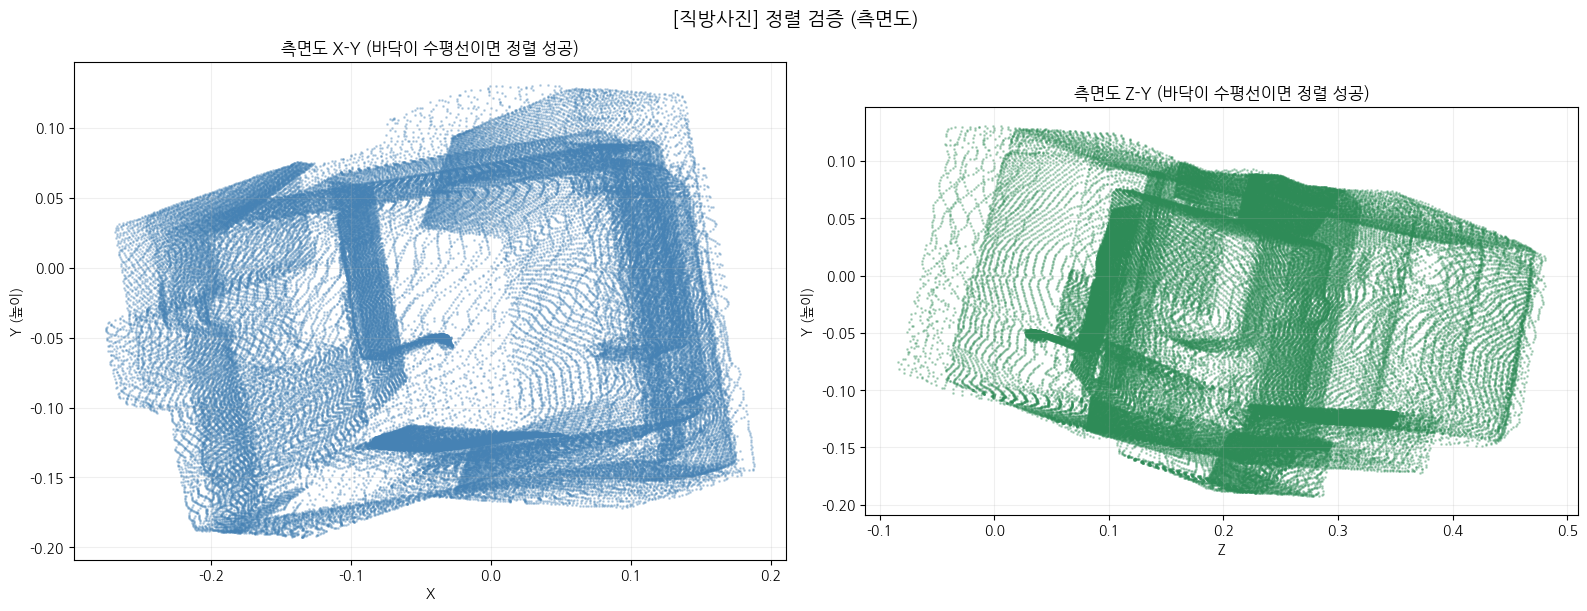

>> 두 측면도에서 바닥이 비스듬하지 않고 수평으로 깔리면 정렬 성공.
>> 여전히 비스듬하면 바닥 후보 비율(percentile 35)이나 입력 품질을 점검.


In [10]:
# 정렬 검증: 바닥이 정말 수평이 됐는지 측면도로 확인
# 정렬이 잘 됐으면 바닥 점들의 Y값이 좁은 띠에 모이고, 벽은 수직으로 선다.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 측면도 (X-Y): 바닥이 수평선으로 보여야 정상
axes[0].scatter(all_pts[::10, 0], all_pts[::10, 1], c="steelblue", s=1, alpha=0.3)
axes[0].set_title("측면도 X-Y (바닥이 수평선이면 정렬 성공)", fontweight="bold")
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y (높이)")
axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.2)

# 또 다른 측면도 (Z-Y)
axes[1].scatter(all_pts[::10, 2], all_pts[::10, 1], c="seagreen", s=1, alpha=0.3)
axes[1].set_title("측면도 Z-Y (바닥이 수평선이면 정렬 성공)", fontweight="bold")
axes[1].set_xlabel("Z"); axes[1].set_ylabel("Y (높이)")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.2)

plt.suptitle(f"[{TARGET_FOLDER}] 정렬 검증 (측면도)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()
print(">> 두 측면도에서 바닥이 비스듬하지 않고 수평으로 깔리면 정렬 성공.")
print(">> 여전히 비스듬하면 바닥 후보 비율(percentile 35)이나 입력 품질을 점검.")


## 4. 3D 모델 저장 (GLB)

객체 라벨 색상 구분 없이 포인트클라우드 전체를 저장한다.

In [11]:
import open3d as o3d
from google.colab import files

# 영문 파일명 (한글명은 다운로드가 멈춤). 폴더명이 한글이어도 출력은 영문으로 고정.
SAFE_NAME = "room"


def clean_pointcloud(points, colors=None, n_neighbors=20, std_ratio=2.0):
    """통계적 이상치 제거"""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    if colors is not None:
        pcd.colors = o3d.utility.Vector3dVector(colors)
    clean, _ = pcd.remove_statistical_outlier(n_neighbors, std_ratio)
    pts = np.asarray(clean.points)
    cols = np.asarray(clean.colors) if colors is not None else None
    return pts, cols


def save_pointcloud_glb(target_name, clean_depth=True):
    room_pts, room_cols = all_pts, all_cols
    if clean_depth:
        room_pts, room_cols = clean_pointcloud(room_pts, room_cols)

    pcd = trimesh.PointCloud(
        vertices=room_pts,
        colors=(room_cols * 255).astype(np.uint8),
    )
    scene_export = trimesh.Scene()
    scene_export.add_geometry(pcd, geom_name="room")

    glb_path = f"/content/{target_name}_pointcloud.glb"
    scene_export.export(glb_path)
    print("저장 완료:", glb_path)
    return glb_path


pcd_glb = save_pointcloud_glb(SAFE_NAME, clean_depth=True)
files.download(pcd_glb)


저장 완료: /content/room_pointcloud.glb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. 천장고 기반 스케일 계산

DUSt3R는 상대 좌표만 복원하므로 실측 거리(m)를 얻으려면 스케일 기준이 필요하다.
한국 원룸의 천장고는 보통 2.3~2.4m로 표준화돼 있어 이를 기준으로 삼는다.

방법: Y(높이) 히스토그램에서 바닥/천장 봉우리 간격을 구하고, 이를 실측 천장고에 맞춰 SCALE을 역산한다.
(단순 min-max는 노이즈로 과대평가되므로 쓰지 않는다.)

In [12]:
CEILING_CANDIDATES = [2.3, 2.4]   # 한국 주거 천장고 표준
UP_AXIS = 1

up = all_pts[:, UP_AXIS]

# 천장고 = Y 히스토그램 바닥/천장 봉우리 간격 (min-max는 노이즈로 과대평가)
hist, edges = np.histogram(up, bins=80)
centers = (edges[:-1] + edges[1:]) / 2
n = len(centers)
floor_peak = centers[:int(n*0.35)][np.argmax(hist[:int(n*0.35)])]
ceil_peak  = centers[int(n*0.65):][np.argmax(hist[int(n*0.65):])]
ceiling_raw = ceil_peak - floor_peak

print(f"바닥 봉우리 Y = {floor_peak:.4f}")
print(f"천장 봉우리 Y = {ceil_peak:.4f}")
print(f"천장고(raw 봉우리 간격) = {ceiling_raw:.4f}")
print(f"(참고) 단순 min-max = {up.max()-up.min():.4f}  <- 노이즈로 과대평가")

print()
for ceil_m in CEILING_CANDIDATES:
    scale = ceil_m / ceiling_raw
    print(f"[천장고 {ceil_m}m 가정] SCALE = {scale:.4f}  (raw 1 단위 = {scale:.4f} m)")

# 거리 측정에 쓸 SCALE: 2.3m 기준
SCALE = CEILING_CANDIDATES[0] / ceiling_raw
print(f"\n>> 거리 측정에 사용할 SCALE = {SCALE:.4f} (천장고 {CEILING_CANDIDATES[0]}m 기준)")


바닥 봉우리 Y = -0.1222
천장 봉우리 Y = 0.0521
천장고(raw 봉우리 간격) = 0.1743
(참고) 단순 min-max = 0.3242  <- 노이즈로 과대평가

[천장고 2.3m 가정] SCALE = 13.1979  (raw 1 단위 = 13.1979 m)
[천장고 2.4m 가정] SCALE = 13.7717  (raw 1 단위 = 13.7717 m)

>> 거리 측정에 사용할 SCALE = 13.1979 (천장고 2.3m 기준)


**확인 포인트 — 천장고 스케일 검증**
- 바닥/천장 봉우리가 히스토그램에서 또렷한 두 덩어리로 보여야 정상이다. 애매하게 퍼져 있으면 정렬(섹션 3) 실패 가능성이 크다.
- 2.3m와 2.4m 기준 SCALE 차이가 크지 않으면(±5% 이내) 안정적인 신호다.
- 이 SCALE이 거리 측정 결과의 정확도를 그대로 좌우한다.

## 6. 두 점 클릭 거리 측정

Plotly 3D 포인트클라우드에서 두 점을 순서대로 클릭하면 실측 거리(m)를 계산한다.

사용법: 아래 셀 실행 → 3D 뷰가 뜨면 마우스로 회전/줌해서 측정하고 싶은 두 점을 찾는다 →
점을 클릭하면 좌표가 선택되고, 두 번째 클릭까지 마치면 자동으로 거리가 출력되고 측정선이 그려진다.
`reset_measurement()`를 실행하면 다시 처음부터 측정할 수 있다.

In [14]:
import plotly.graph_objects as go
from ipywidgets import Output
from IPython.display import display

# 시각화용 다운샘플 (전체를 다 그리면 클릭 반응이 느려진다)
DISPLAY_STRIDE = 5
disp_pts = all_pts[::DISPLAY_STRIDE]
disp_cols = all_cols[::DISPLAY_STRIDE]
disp_cols_str = [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r, g, b in disp_cols]

_selected_points = []   # 클릭으로 모은 (x,y,z) raw 좌표, 최대 2개
_out = Output()


def _make_base_figure():
    fig = go.FigureWidget(
        data=[go.Scatter3d(
            x=disp_pts[:, 0], y=disp_pts[:, 1], z=disp_pts[:, 2],
            mode="markers",
            marker=dict(size=2, color=disp_cols_str, opacity=0.85),
            name="room",
        )]
    )
    fig.update_layout(
        title=f"[{TARGET_FOLDER}] 두 점 클릭 → 거리 측정 (SCALE={SCALE:.4f})",
        scene=dict(
            xaxis_title="X", yaxis_title="Y (높이)", zaxis_title="Z",
            aspectmode="data",
        ),
        width=900, height=750,
        margin=dict(l=0, r=0, t=40, b=0),
    )
    return fig


fig = _make_base_figure()


def _on_click(trace, points, state):
    if not points.point_inds:
        return
    idx = points.point_inds[0]
    p = np.array([disp_pts[idx, 0], disp_pts[idx, 1], disp_pts[idx, 2]])

    if len(_selected_points) >= 2:
        _selected_points.clear()
        # 측정선/마커 흔적 정리 (base trace만 남기고 재구성)
        fig.data = [fig.data[0]]

    _selected_points.append(p)

    with _out:
        print(f"점 {len(_selected_points)} 선택: "
              f"[{p[0]:+.4f}, {p[1]:+.4f}, {p[2]:+.4f}]  (raw)")

    # 선택한 점 강조 표시
    fig.add_trace(go.Scatter3d(
        x=[p[0]], y=[p[1]], z=[p[2]],
        mode="markers",
        marker=dict(size=8, color="red", symbol="diamond"),
        name=f"point_{len(_selected_points)}",
        showlegend=False,
    ))

    if len(_selected_points) == 2:
        p1, p2 = _selected_points
        dist_raw = np.linalg.norm(p2 - p1)
        dist_m = dist_raw * SCALE

        fig.add_trace(go.Scatter3d(
            x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
            mode="lines",
            line=dict(color="red", width=6),
            name="measurement",
            showlegend=False,
        ))

        with _out:
            print(f"\n>> 측정 거리: {dist_m:.3f} m  (raw={dist_raw:.4f}, SCALE={SCALE:.4f})\n")


fig.data[0].on_click(_on_click)


def reset_measurement():
    """측정 초기화 (다시 두 점 클릭부터 시작)"""
    _selected_points.clear()
    fig.data = [fig.data[0]]
    with _out:
        print("측정 초기화 완료. 다시 두 점을 클릭하세요.")


display(fig)
display(_out)
print("3D 뷰에서 점 두 개를 순서대로 클릭하면 거리가 계산됩니다.")
print("다시 측정하려면 reset_measurement() 를 실행하세요.")


FigureWidget({
    'data': [{'marker': {'color': [rgb(66,55,33), rgb(53,42,19), rgb(54,43,21),
                                   ..., rgb(77,77,78), rgb(77,77,77),
                                   rgb(76,76,76)],
                         'opacity': 0.85,
                         'size': 2},
              'mode': 'markers',
              'name': 'room',
              'type': 'scatter3d',
              'uid': '5fae68e5-9320-4ba8-b15e-708b5f1399cf',
              'x': array([ 0.1180837 ,  0.11684772,  0.11516395, ..., -0.06235881, -0.0613166 ,
                          -0.06005098]),
              'y': array([ 0.08951793,  0.09009377,  0.09042075, ..., -0.08246826, -0.08118456,
                          -0.07923301]),
              'z': array([0.13280285, 0.13418103, 0.13525075, ..., 0.06697845, 0.06699637,
                          0.06877463])}],
    'layout': {'height': 750,
               'margin': {'b': 0, 'l': 0, 'r': 0, 't': 40},
               'scene': {'aspectmode': 'data',
  

Output()

3D 뷰에서 점 두 개를 순서대로 클릭하면 거리가 계산됩니다.
다시 측정하려면 reset_measurement() 를 실행하세요.


**참고 — 클릭 측정 정확도 팁**
- `DISPLAY_STRIDE`를 줄이면(예: 2) 점이 촘촘해져 클릭 정밀도가 올라가지만 렌더링이 느려진다.
- 클릭이 잘 안 잡히면 줌을 충분히 키운 상태에서 시도한다 (포인트가 화면상에서 너무 작으면 클릭 판정이 어렵다).
- raw 좌표가 이상하게 튀는 점(노이즈)을 클릭하면 거리가 비정상적으로 나올 수 있다 — confidence가 낮은 영역(섹션 2-1 참고)은 피한다.
- 같은 방식으로 여러 구간(예: 침대 가로/세로, 문~창문 거리)을 반복 측정해 천장고 스케일의 일관성을 검증할 수 있다.

## 마무리: 결과가 부족할 때 체크리스트

- **측정 거리가 비현실적이다** → 섹션 5 천장고 스케일부터 의심. 바닥/천장 봉우리가 또렷한지 히스토그램 확인.
- **바닥이 기울어 보인다** → 섹션 3 정렬 검증(측면도)에서 바닥이 수평선인지 확인. 아니면 바닥 후보 percentile(35) 조정.
- **점군이 너무 듬성듬성하다** → `CONF_THR`을 낮추거나(노이즈 증가 트레이드오프), 입력 사진을 늘린다.
- **클릭이 원하는 점을 못 잡는다** → `DISPLAY_STRIDE`를 줄여 점 밀도를 높이고, 줌을 키운 상태에서 클릭.
- **천장고 자체가 표준(2.3~2.4m)과 다른 매물이다** → `CEILING_CANDIDATES`를 실측값으로 바꿔서 SCALE 재계산.
